In [73]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from collections import defaultdict

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [74]:
conn = sqlite3.connect("../data/sample_strategy/sample_v4.db")

query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql(query, conn)
print(tables)

              name
0   NearsestSample
1  sqlite_sequence


In [75]:
df = pd.read_sql("SELECT * FROM NearsestSample", conn)

df = df[(df["TimeDim"] >= 2010) & (df["TimeDim"] <= 2015)].reset_index(drop=True)

In [76]:
# Kiểm tra dữ liệu thô
print(df.shape)
print(df.head().T)
print(df.sample(5).T)
# Kiểm tra duplicate
print(df.duplicated().sum())
df = df.drop_duplicates()

(10956, 13)
                0      1      2      3      4
id              6     17     20     30     37
y          134.90 136.10 135.90 135.60 135.20
x1          29.96  56.00  58.05 481.64 561.07
x2          23.82  11.37  11.44  22.73  11.99
x3          26.10  26.60  26.50  26.40  26.20
x4           5.00   4.90   4.90   5.00   5.00
x5           7.20  54.18   7.70   7.60   7.30
x6           7.90   8.40   8.40   8.30   8.00
x7            NaN   0.18   0.17   0.18    NaN
x8          24.71  25.52  25.33  25.15  17.84
x9          28.10   7.40   7.40   7.40  28.10
SpatialDim    ALB    ALB    ALB    ALB    ALB
TimeDim      2010   2015   2014   2013   2011
             10254     7130   9927   10142  3129 
id           55183     38350  53422  54556  16846
y            20.20    134.20  37.00  37.60  49.90
x1         1146.64 155867.18  97.74 225.49   7.05
x2           34.68     53.10  65.36  47.10   4.20
x3            4.17     22.60  50.64  11.55  20.72
x4            2.80      3.50   3.70   3.10  

In [77]:
df = df.drop(columns=["id","x7","SpatialDim"], errors="ignore")
df.columns = [
    'cardiovascular_diseases',
    'air_pollution',
    'alcohol_consumption',
    'BMI',
    'cholesterol',
    'diabetes',
    'glucose',
    'physical_activities',
    'tobacco',
    'time'
]

In [78]:
# %%
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10956 entries, 0 to 10955
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cardiovascular_diseases  10956 non-null  float64
 1   air_pollution            10890 non-null  float64
 2   alcohol_consumption      10735 non-null  float64
 3   BMI                      10956 non-null  float64
 4   cholesterol              10956 non-null  float64
 5   diabetes                 10956 non-null  float64
 6   glucose                  10956 non-null  float64
 7   physical_activities      10956 non-null  float64
 8   tobacco                  10956 non-null  float64
 9   time                     10956 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 856.1 KB


In [79]:
# %%
df.isnull().sum()

cardiovascular_diseases      0
air_pollution               66
alcohol_consumption        221
BMI                          0
cholesterol                  0
diabetes                     0
glucose                      0
physical_activities          0
tobacco                      0
time                         0
dtype: int64

In [80]:
missing_ratio = df.isnull().mean()*100
print(missing_ratio)

cardiovascular_diseases   0.00
air_pollution             0.60
alcohol_consumption       2.02
BMI                       0.00
cholesterol               0.00
diabetes                  0.00
glucose                   0.00
physical_activities       0.00
tobacco                   0.00
time                      0.00
dtype: float64


In [81]:
# %%
df = df.fillna(df.mean(numeric_only=True))

In [82]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cardiovascular_diseases,10956.00,55.59,35.51,8.70,32.77,40.40,62.10,137.50
air_pollution,10956.00,8290.69,319532.74,0.00,51.07,193.72,582.01,25095186.19
alcohol_consumption,10956.00,41.43,19.26,2.68,26.66,40.18,52.41,99.22
BMI,10956.00,22.42,17.62,0.24,7.45,22.20,27.20,92.47
cholesterol,10956.00,2.90,1.43,0.80,1.30,3.30,4.00,5.30
diabetes,10956.00,16.68,16.74,2.80,5.69,8.00,20.60,83.10
glucose,10956.00,8.66,4.24,2.10,5.90,8.00,9.80,29.80
physical_activities,10956.00,26.06,11.77,3.34,17.58,23.77,32.64,69.21
tobacco,10956.00,23.76,14.74,0.00,12.47,23.00,32.80,77.00
time,10956.00,2012.50,1.71,2010.00,2011.00,2012.50,2014.00,2015.00


<Axes: xlabel='air_pollution', ylabel='Count'>

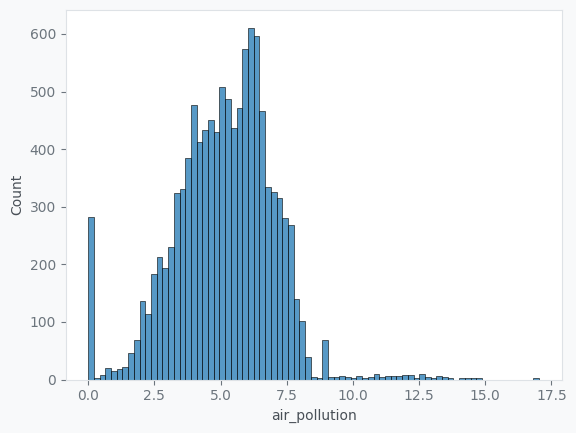

In [83]:
df['air_pollution'] = np.log1p(df['air_pollution'])
sns.histplot(df['air_pollution'])

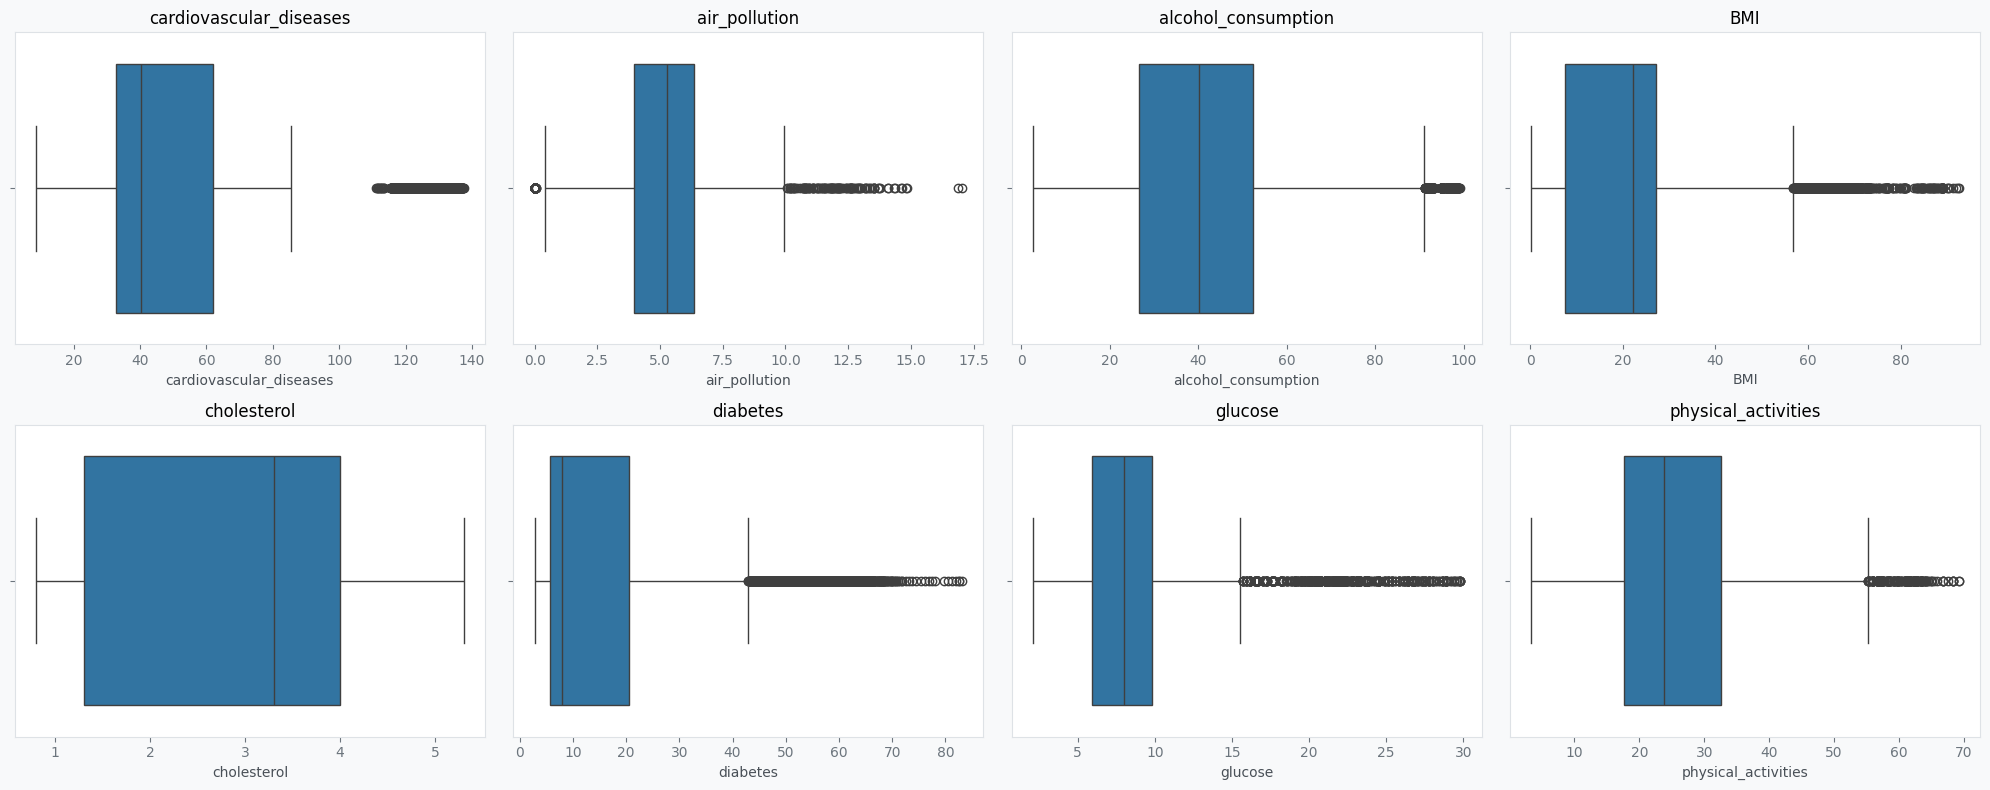

In [84]:
cols = df.columns[:-1]

plt.figure(figsize=(20,8))

for i, col in enumerate(cols[:8]):
    plt.subplot(2,4,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

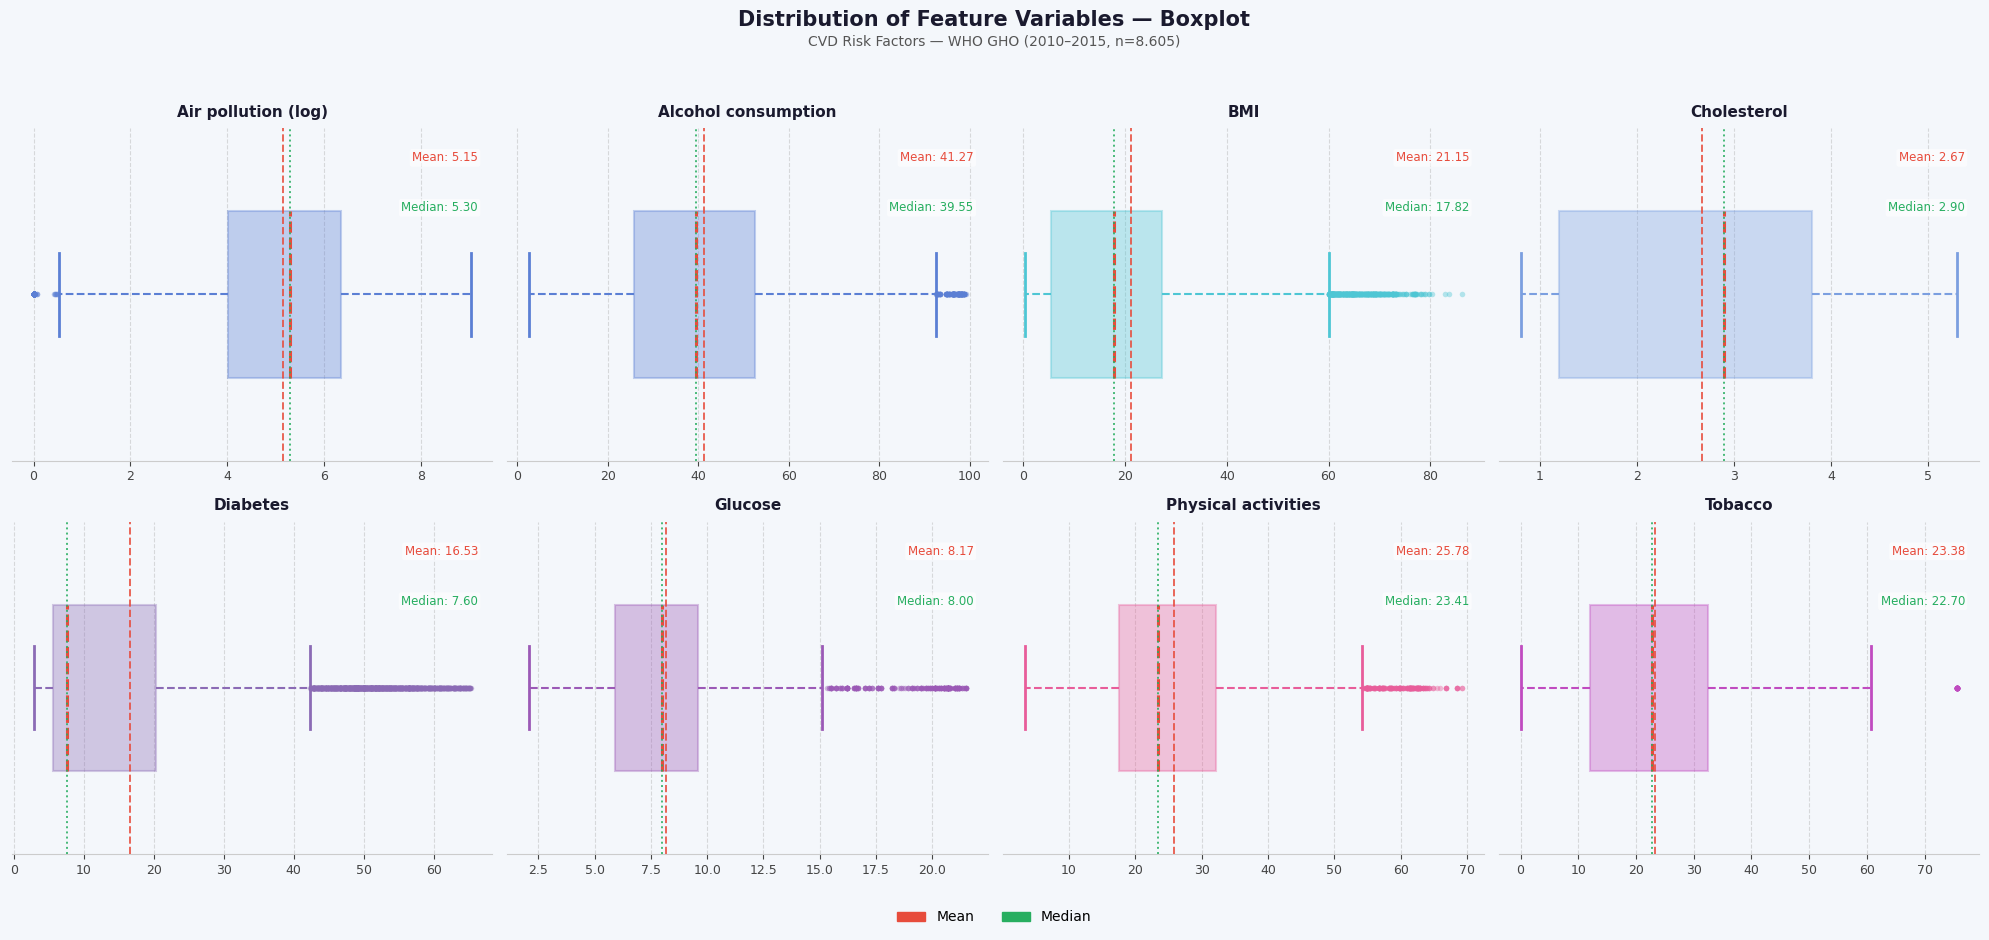

In [165]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# --- Mapping tên biến → tiếng Việt + màu sắc ---
var_config = {
    'air_pollution':          {'label': 'Air pollution (log)', 'color': '#5B7FD4'},
    'alcohol_consumption':    {'label': 'Alcohol consumption',        'color': '#5B7FD4'},
    'BMI':                    {'label': 'BMI',               'color': '#4EC6D4'},
    'cholesterol':            {'label': 'Cholesterol',              'color': '#7B9FE0'},
    'diabetes':               {'label': 'Diabetes',               'color': '#8B6BB5'},
    'glucose':                {'label': 'Glucose',                  'color': '#9B59B6'},
    'physical_activities':    {'label': 'Physical activities',       'color': '#E85D9A'},
    'tobacco':                {'label': 'Tobacco',                 'color': '#C04BC0'},
}

cols = [c for c in var_config if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.patch.set_facecolor('#F4F7FB')
axes = axes.flatten()

for i, col in enumerate(cols[:8]):
    ax = axes[i]
    ax.set_facecolor('#F4F7FB')

    cfg   = var_config[col]
    color = cfg['color']
    data  = df[col].dropna()

    # --- Boxplot nằm ngang ---
    ax.boxplot(
        data,
        vert=False,
        patch_artist=True,
        widths=0.5,
        boxprops    =dict(facecolor=color, alpha=0.35, linewidth=1.5, edgecolor=color),
        medianprops =dict(color='#E74C3C', linewidth=2.2, linestyle='--'),
        whiskerprops=dict(color=color, linewidth=1.5, linestyle='--'),
        capprops    =dict(color=color, linewidth=2),
        flierprops  =dict(marker='o', markerfacecolor=color, alpha=0.4,
                          markersize=4, linestyle='none', markeredgewidth=0),
    )

    # --- Đường Mean & Median ---
    mean_val   = data.mean()
    median_val = data.median()
    ax.axvline(mean_val,   color='#E74C3C', linewidth=1.4,
               linestyle='--', alpha=0.85, zorder=3)
    ax.axvline(median_val, color='#27AE60', linewidth=1.4,
               linestyle=':',  alpha=0.85, zorder=3)

    # --- Annotation mean / median ---
    ax.text(0.97, 0.93, f'Mean: {mean_val:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8.5, color='#E74C3C',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))
    ax.text(0.97, 0.78, f'Median: {median_val:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8.5, color='#27AE60',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

    # --- Style trục ---
    ax.set_title(cfg['label'], fontsize=11, fontweight='bold',
                 color='#1a1a2e', pad=8)
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=9, colors='#444')
    ax.set_xlabel('')
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#ccc')
    ax.grid(axis='x', linestyle='--', alpha=0.4, color='#aaa')

# --- Legend chung ---
legend_handles = [
    mpatches.Patch(color='#E74C3C', label='Mean'),
    mpatches.Patch(color='#27AE60', label='Median'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, -0.01))

# --- Tiêu đề chính ---
fig.suptitle(
    'Distribution of Feature Variables — Boxplot',
    fontsize=15, fontweight='bold', color='#1a1a2e', y=1.02
)
fig.text(0.5, 0.98,
         'CVD Risk Factors — WHO GHO (2010–2015, n=8.605)',
         ha='center', fontsize=10, color='#555')

plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.savefig('boxplot_features.png', dpi=180,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

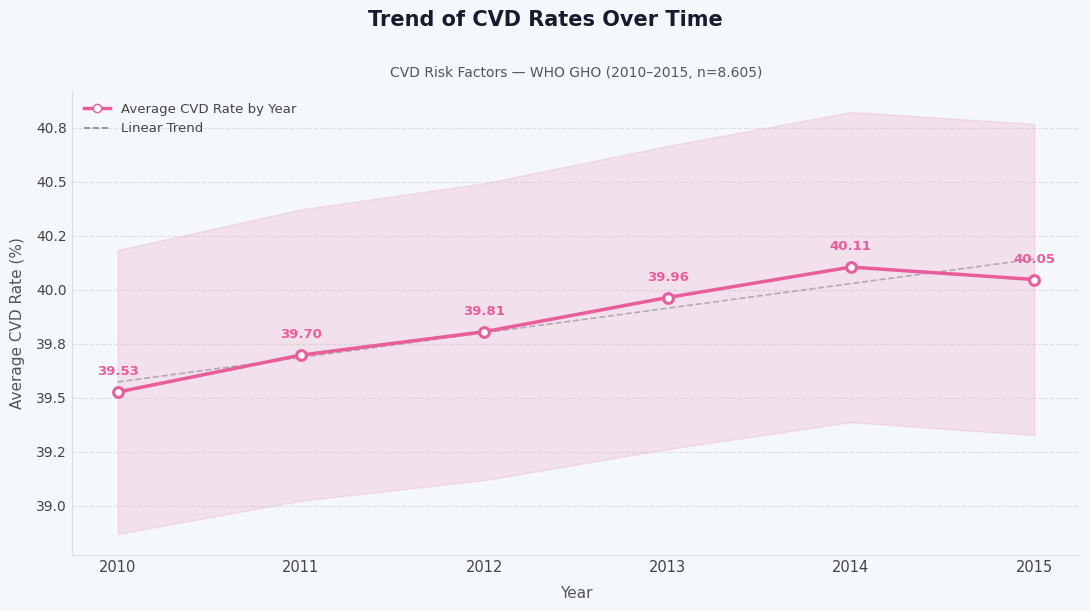

In [157]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

# --- Group theo năm, tính mean CVD rate ---
cvd_trend = (
    df.groupby('time')['cardiovascular_diseases']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
cvd_trend.columns = ['year', 'mean', 'std', 'count']

# Confidence interval 95%
cvd_trend['ci'] = 1.96 * cvd_trend['std'] / np.sqrt(cvd_trend['count'])

# --- Setup ---
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#F4F7FB')
ax.set_facecolor('#F4F7FB')

color_line = '#E85D9A'
color_ci   = '#E85D9A'

years = cvd_trend['year']
means = cvd_trend['mean']
ci    = cvd_trend['ci']

# --- Vùng CI ---
ax.fill_between(years, means - ci, means + ci,
                color=color_ci, alpha=0.15, zorder=1)

# --- Đường trend chính ---
ax.plot(years, means,
        color=color_line, linewidth=2.5,
        marker='o', markersize=7,
        markerfacecolor='white', markeredgewidth=2.2,
        markeredgecolor=color_line, zorder=3)

# --- Annotation giá trị từng năm ---
for _, row in cvd_trend.iterrows():
    ax.annotate(
        f"{row['mean']:.2f}",
        xy=(row['year'], row['mean']),
        xytext=(0, 12), textcoords='offset points',
        ha='center', fontsize=9.5, color=color_line, fontweight='bold'
    )

# --- Đường xu hướng tuyến tính (trendline) ---
z    = np.polyfit(years, means, 1)
p    = np.poly1d(z)
x_smooth = np.linspace(years.min(), years.max(), 200)
ax.plot(x_smooth, p(x_smooth),
        color='#888', linewidth=1.2,
        linestyle='--', alpha=0.6, zorder=2, label='Linear trend')

# --- Style trục ---
ax.set_xticks(years)
ax.set_xticklabels([str(int(y)) for y in years], fontsize=10.5, color='#444')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.tick_params(axis='y', labelsize=10, colors='#444')
ax.tick_params(axis='both', length=0)

ax.set_xlabel('Year', fontsize=11, color='#555', labelpad=8)
ax.set_ylabel('Average CVD Rate (%)', fontsize=11, color='#555', labelpad=8)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#ddd')
ax.spines['bottom'].set_color('#ddd')
ax.grid(axis='y', linestyle='--', alpha=0.4, color='#bbb')

# --- Legend ---
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color=color_line, linewidth=2.5,
           marker='o', markerfacecolor='white',
           markeredgecolor=color_line, label='Average CVD Rate by Year'),
    Line2D([0], [0], color='#888', linewidth=1.2,
           linestyle='--', label='Linear Trend'),
]
ax.legend(handles=handles, fontsize=9.5, frameon=False,
          loc='upper left', labelcolor='#444')

# --- Tiêu đề ---
fig.suptitle('Trend of CVD Rates Over Time',
             fontsize=15, fontweight='bold', color='#1a1a2e', y=1.01)
ax.set_title('CVD Risk Factors — WHO GHO (2010–2015, n=8.605)',
             fontsize=10, color='#555', pad=10)

plt.tight_layout()
plt.savefig('cvd_trend.png', dpi=180,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [87]:
df_original = df.copy()

df = df_original.copy()
mask = pd.Series(True, index=df.index)

for col in cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR

    mask &= (df[col] >= lower) & (df[col] <= upper)

df = df[mask]
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cardiovascular_diseases,10516.00,55.57,35.54,8.70,32.56,40.40,62.40,137.50
air_pollution,10516.00,5.21,1.77,0.00,4.01,5.32,6.38,13.55
alcohol_consumption,10516.00,41.12,19.34,2.68,26.33,39.56,52.09,99.22
BMI,10516.00,21.95,16.73,0.28,7.64,22.09,27.00,86.22
cholesterol,10516.00,2.90,1.42,0.80,1.30,3.30,4.00,5.30
diabetes,10516.00,15.99,16.11,2.80,5.64,7.80,17.90,65.31
glucose,10516.00,8.17,3.24,2.10,5.90,8.00,9.60,21.50
physical_activities,10516.00,25.78,11.75,3.34,17.46,23.45,32.15,69.21
tobacco,10516.00,23.34,14.65,0.00,12.00,22.70,32.50,77.00
time,10516.00,2012.48,1.71,2010.00,2011.00,2012.00,2014.00,2015.00


In [88]:
df = df[df['cardiovascular_diseases'] <= 100].reset_index(drop=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cardiovascular_diseases,8605.00,39.86,13.39,8.70,31.30,37.30,46.00,85.60
air_pollution,8605.00,5.15,1.64,0.00,4.01,5.30,6.35,9.02
alcohol_consumption,8605.00,41.27,20.18,2.68,25.91,39.55,52.60,99.22
BMI,8605.00,21.15,18.37,0.28,5.45,17.82,27.29,86.22
cholesterol,8605.00,2.67,1.44,0.80,1.20,2.90,3.80,5.30
diabetes,8605.00,16.53,16.65,2.80,5.53,7.60,20.27,65.26
glucose,8605.00,8.17,3.24,2.10,5.90,8.00,9.60,21.50
physical_activities,8605.00,25.78,11.77,3.34,17.45,23.41,32.15,69.21
tobacco,8605.00,23.38,14.65,0.00,12.00,22.70,32.50,75.70
time,8605.00,2012.48,1.71,2010.00,2011.00,2012.00,2014.00,2015.00


In [89]:
# =================================================================
# Trích xuất thống kê mô tả — khớp với bảng trong report
# ĐẶT: ngay sau cell df.describe().T (sau khi đã lọc IQR xong)
# =================================================================

import pandas as pd

# ── Tên hiển thị tiếng Việt ────────────────────────────────────
labels_vi = {
    'cardiovascular_diseases': 'CVD Rate',
    'air_pollution':            'Ô nhiễm KK*',
    'alcohol_consumption':      'Rượu bia',
    'BMI':                      'BMI',
    'cholesterol':              'Cholesterol',
    'diabetes':                 'Tiểu đường',
    'glucose':                  'Glucose',
    'physical_activities':      'Hoạt động TC',
    'tobacco':                  'Thuốc lá',
}

# ── Thứ tự cột cần hiển thị ────────────────────────────────────
cols_order = [
    'cardiovascular_diseases',
    'air_pollution',
    'alcohol_consumption',
    'BMI',
    'cholesterol',
    'diabetes',
    'glucose',
    'physical_activities',
    'tobacco',
]

# ── Tính thống kê ──────────────────────────────────────────────
stats = df[cols_order].agg(['mean', 'std', 'min', 'max']).T
stats.columns = ['TB', 'Std', 'Min', 'Max']
stats = stats.round(2)
stats.index = [labels_vi[c] for c in cols_order]

print(f"Tập dữ liệu sau lọc IQR×3: n = {len(df):,} bản ghi\n")
print(stats.to_string())
print("\n* Giá trị sau biến đổi log1p")

# ── Export sang LaTeX (dùng thẳng vào report) ─────────────────
latex_str = stats.to_latex(
    float_format="%.2f",
    caption="Thống kê mô tả sau lọc ngoại lệ ($n=10.516$)",
    label="tab:descriptive",
    bold_rows=False,
)
print("\n" + "─"*60)
print("LaTeX output:")
print("─"*60)
print(latex_str)

Tập dữ liệu sau lọc IQR×3: n = 8,605 bản ghi

                TB   Std  Min   Max
CVD Rate     39.86 13.39 8.70 85.60
Ô nhiễm KK*   5.15  1.64 0.00  9.02
Rượu bia     41.27 20.18 2.68 99.22
BMI          21.15 18.37 0.28 86.22
Cholesterol   2.67  1.44 0.80  5.30
Tiểu đường   16.53 16.65 2.80 65.26
Glucose       8.17  3.24 2.10 21.50
Hoạt động TC 25.78 11.77 3.34 69.21
Thuốc lá     23.38 14.65 0.00 75.70

* Giá trị sau biến đổi log1p

────────────────────────────────────────────────────────────
LaTeX output:
────────────────────────────────────────────────────────────
\begin{table}
\caption{Thống kê mô tả sau lọc ngoại lệ ($n=10.516$)}
\label{tab:descriptive}
\begin{tabular}{lrrrr}
\toprule
 & TB & Std & Min & Max \\
\midrule
CVD Rate & 39.86 & 13.39 & 8.70 & 85.60 \\
Ô nhiễm KK* & 5.15 & 1.64 & 0.00 & 9.02 \\
Rượu bia & 41.27 & 20.18 & 2.68 & 99.22 \\
BMI & 21.15 & 18.37 & 0.28 & 86.22 \\
Cholesterol & 2.67 & 1.44 & 0.80 & 5.30 \\
Tiểu đường & 16.53 & 16.65 & 2.80 & 65.26 \\
Glucose & 8

In [90]:
df_model = df.copy()

y = df_model['cardiovascular_diseases']

X = df_model.drop(columns=['cardiovascular_diseases','time'])
print(X)

feature_names = X.columns

      air_pollution  alcohol_consumption   BMI  cholesterol  diabetes  \
0              4.02                23.85 26.50         1.30      7.10   
1              2.85                43.61 26.80         1.30      7.40   
2              5.70                19.09 26.40         1.30      7.10   
3              6.57                24.15  1.42         5.00      5.08   
4              5.87                22.51 26.90         1.30     54.30   
...             ...                  ...   ...          ...       ...   
8600           4.53                55.62 30.72         1.20     21.20   
8601           7.68                49.61 15.89         2.80      7.60   
8602           4.51                48.89 16.44         2.70      5.03   
8603           6.67                49.47 40.00         1.30      6.70   
8604           7.27                49.61 41.17         1.20      5.02   

      glucose  physical_activities  tobacco  
0        7.90                24.84     8.30  
1        8.30                21

In [91]:
scaler1 = StandardScaler()
X_sm = scaler1.fit_transform(X)
X_with_constant = sm.add_constant(X_sm)

model_sm = sm.OLS(y,X_with_constant)
result_sm = model_sm.fit()

print(result_sm.summary())

                               OLS Regression Results                              
Dep. Variable:     cardiovascular_diseases   R-squared:                       0.108
Model:                                 OLS   Adj. R-squared:                  0.107
Method:                      Least Squares   F-statistic:                     129.8
Date:                     Sun, 22 Mar 2026   Prob (F-statistic):          2.08e-206
Time:                             10:33:19   Log-Likelihood:                -34044.
No. Observations:                     8605   AIC:                         6.811e+04
Df Residuals:                         8596   BIC:                         6.817e+04
Df Model:                                8                                         
Covariance Type:                 nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

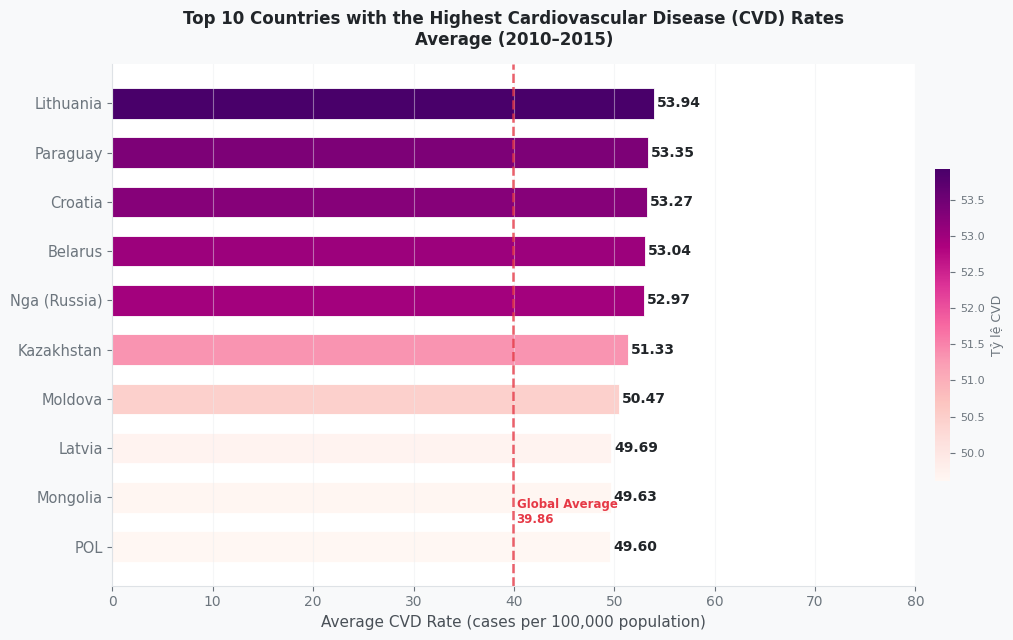

✅ Đã lưu: top10_countries.png


In [155]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Style khớp với distribution_plots ──────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.edgecolor':   '#DEE2E6',
    'axes.labelcolor':  '#495057',
    'xtick.color':      '#6C757D',
    'ytick.color':      '#6C757D',
    'grid.color':       '#E9ECEF',
    'font.family':      'DejaVu Sans',
})

# ── Query SQL ───────────────────────────────────────────────────
conn = sqlite3.connect("../data/sample_strategy/sample_v4.db")
df_top = pd.read_sql("""
    SELECT SpatialDim AS country,
           ROUND(AVG(y), 2) AS avg_cvd,
           COUNT(*) AS records
    FROM NearsestSample
    WHERE TimeDim BETWEEN 2010 AND 2015
      AND y IS NOT NULL
      AND y < 100
    GROUP BY SpatialDim
    ORDER BY avg_cvd DESC
    LIMIT 10
""", conn)
conn.close()

# ── Tên quốc gia tiếng Việt / đầy đủ ──────────────────────────
country_names = {
    'LTU': 'Lithuania',
    'HRV': 'Croatia',
    'BLR': 'Belarus',
    'PRY': 'Paraguay',
    'RUS': 'Nga (Russia)',
    'KAZ': 'Kazakhstan',
    'MDA': 'Moldova',
    'LVA': 'Latvia',
    'MNG': 'Mongolia',
    'ROU': 'Romania',
}
df_top['label'] = df_top['country'].map(lambda x: country_names.get(x, x))
df_top = df_top.sort_values('avg_cvd', ascending=True).reset_index(drop=True)

global_mean = 39.86

# ── Màu gradient theo giá trị (khớp palette histogram) ─────────
norm = plt.Normalize(df_top['avg_cvd'].min(), df_top['avg_cvd'].max())
cmap = plt.cm.RdPu   # hồng → tím, hợp với palette của histogram
bar_colors = [cmap(norm(v)) for v in df_top['avg_cvd']]

# ── Vẽ biểu đồ ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

bars = ax.barh(
    df_top['label'], df_top['avg_cvd'],
    color=bar_colors, height=0.62,
    edgecolor='white', linewidth=0.6
)

# Nhãn giá trị bên phải thanh
for bar, val in zip(bars, df_top['avg_cvd']):
    ax.text(
        val + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center', ha='left',
        fontsize=10, fontweight='600',
        color='#212529'
    )

# Đường trung bình toàn cầu
ax.axvline(global_mean, color='#E63946',
           linestyle='--', linewidth=1.8, alpha=0.8)
ax.text(
    global_mean + 0.4, 0.42,
    f'Global Average\n{global_mean}',
    fontsize=8.5, color='#E63946',
    va='bottom', fontweight='600'
)

# ── Nhãn & tiêu đề ─────────────────────────────────────────────
ax.set_xlabel('Average CVD Rate (cases per 100,000 population)', fontsize=11)
ax.set_title(
    'Top 10 Countries with the Highest Cardiovascular Disease (CVD) Rates\n'
    'Average (2010–2015)',
    fontsize=12, fontweight='bold',
    color='#212529', pad=14
)
ax.set_xlim(0, 80)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', alpha=0.45, linewidth=0.8)
ax.tick_params(axis='y', labelsize=10.5)

# Colorbar nhỏ bên phải làm legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Tỷ lệ CVD', fontsize=9, color='#6C757D')
cbar.ax.tick_params(labelsize=8, colors='#6C757D')
cbar.outline.set_visible(False)

plt.tight_layout()
plt.savefig('top10_countries.png',
            dpi=180, bbox_inches='tight',
            facecolor='#F8F9FA')
plt.show()
print("✅ Đã lưu: top10_countries.png")

In [94]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
 
# ── Global style (copy 1 lần ở đầu notebook) ───────────────────
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.edgecolor':   '#DEE2E6',
    'axes.labelcolor':  '#495057',
    'xtick.color':      '#6C757D',
    'ytick.color':      '#6C757D',
    'grid.color':       '#E9ECEF',
    'font.family':      'DejaVu Sans',
})
 
PALETTE = ['#4361EE','#3A86FF','#4CC9F0','#4895EF',
           '#560BAD','#7209B7','#F72585','#B5179E']
ACCENT  = '#E63946'

In [95]:
# Thử tiến hành sử dụng mô hình lý giải
def run_for_linear(X_train, X_test, y_train, y_test):

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
    print("R2:", r2_score(y_test, y_pred))

    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    return model.coef_, model.intercept_, y_pred 

In [96]:
coef, inter, y_pred_lr = run_for_linear(X_train, X_test, y_train, y_test)

RMSE: 12.529882295232966
R2: 0.09552943729763674
Coefficients: [ 0.10303571 -2.4337713  -0.91616523  2.52664423 -1.8300112   2.04960245
  0.44446789 -0.09161411]
Intercept: 39.91036666804184


In [97]:
def softmax(z):
    z_shifted = z - np.max(z)   # tránh overflow
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

In [98]:
importance = np.abs(coef)
importance = importance / importance.sum()

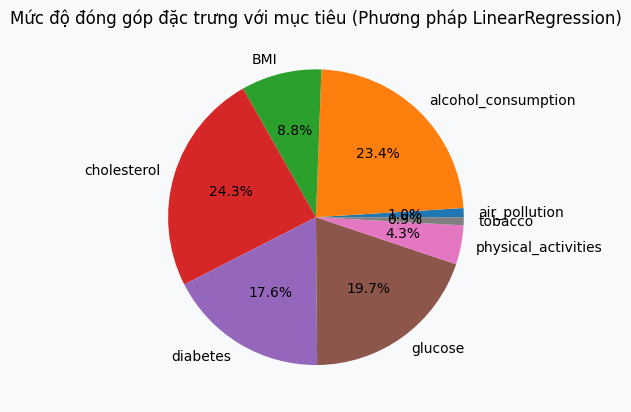

In [99]:
# Vẽ biểu đồ đối với Linear
# Thử vẽ biểu đồ đóng góp
# Biểu đồ này ko có ý nghĩa do ko giải thích được hết dữ liệu

plt.figure()
plt.pie(importance, labels=feature_names, autopct='%1.1f%%')
plt.title('Mức độ đóng góp đặc trưng với mục tiêu (Phương pháp LinearRegression)')
plt.show()

In [100]:
def run_for_random_forest(X_train, X_test, y_train, y_test):

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
    print("R2:", r2_score(y_test, y_pred))

    print("Feature Importances:", model.feature_importances_)
    return model.feature_importances_, y_pred

In [101]:
impor, y_pred_rf = run_for_random_forest(X_train, X_test, y_train, y_test)

RMSE: 9.493727544868976
R2: 0.4807530166661974
Feature Importances: [0.00378944 0.06451446 0.44498126 0.24994588 0.12873835 0.09088146
 0.01522668 0.00192247]


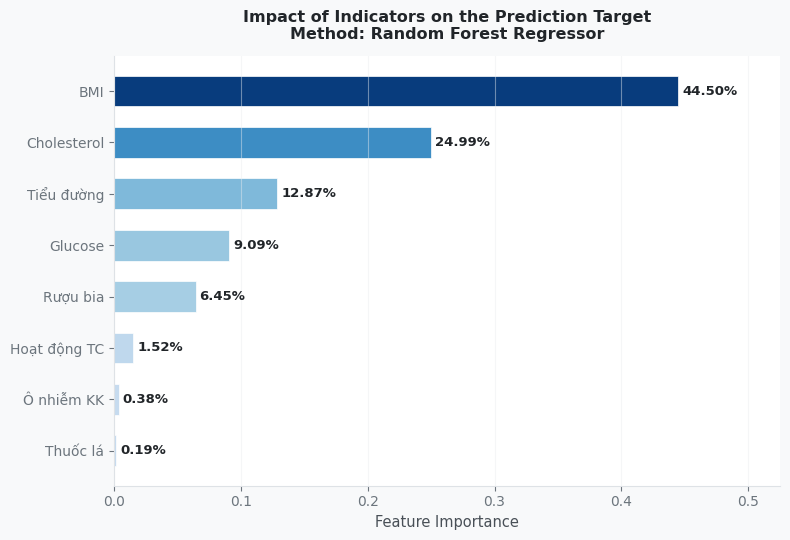

✅ rf_importance.png


In [163]:
fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

importances = impor.tolist()           # biến từ run_for_random_forest()
labels_vi = [
    'Ô nhiễm KK', 'Rượu bia', 'BMI', 'Cholesterol',
    'Tiểu đường', 'Glucose', 'Hoạt động TC', 'Thuốc lá'
]
sorted_idx = np.argsort(importances)
sorted_imp = [importances[i] for i in sorted_idx]
sorted_lbl = [labels_vi[i] for i in sorted_idx]
 
norm_rf = plt.Normalize(min(sorted_imp), max(sorted_imp))
bar_colors_rf = [plt.cm.Blues(norm_rf(v) * 0.7 + 0.25) for v in sorted_imp]
 
bars = ax.barh(sorted_lbl, sorted_imp,
               color=bar_colors_rf, height=0.6,
               edgecolor='white', linewidth=0.5)
 
for bar, val in zip(bars, sorted_imp):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val*100:.2f}%', va='center', ha='left',
            fontsize=9.5, fontweight='600', color='#212529')
 
ax.set_xlabel('Feature Importance', fontsize=10.5)
ax.set_title(
    'Impact of Indicators on the Prediction Target\n'
    'Method: Random Forest Regressor',
    fontsize=11.5, fontweight='bold', color='#212529', pad=12
)
ax.set_xlim(0, max(sorted_imp) * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', alpha=0.45, linewidth=0.8)
ax.tick_params(axis='y', labelsize=10)
 
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ rf_importance.png")

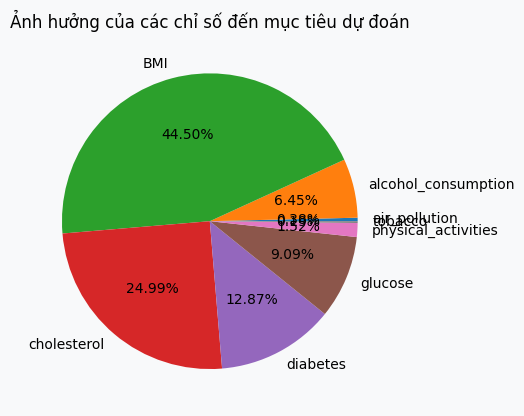

In [103]:
plt.figure()
plt.pie(impor.tolist(), labels=feature_names, autopct='%1.2f%%')
plt.title('Ảnh hưởng của các chỉ số đến mục tiêu dự đoán')
plt.show()

In [104]:
def draw_contribution(groups : dict = None, title=""):
    # Tiến hành tiền xử lí sơ sơ
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)
    # Tạo bảng ánh xạ để hiển thị dữ liệu
    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    # Định dạng của groups 
    # str --> tên groups
    for col, val in zip(feature_names, impor.tolist()):
        values[mapping[col]] += val

    # Thử vẽ biểu đồ đóng góp
    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()

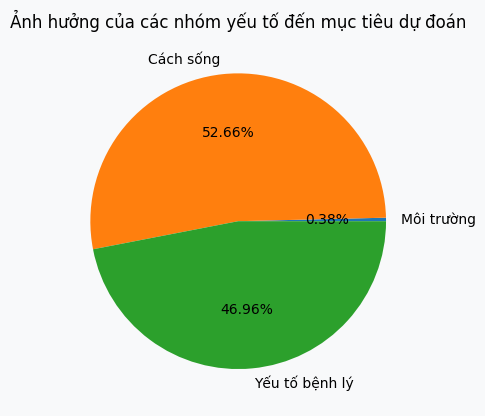

In [105]:
draw_contribution(groups={
    'Cách sống' : ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Môi trường' : ['air_pollution'],
    'Yếu tố bệnh lý' : ['cholesterol', 'diabetes', 'glucose']
}, title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán")

In [106]:
from xgboost import XGBRegressor


In [107]:
def run_for_xgboost(X_train, X_test, y_train, y_test):

    model = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
    print("R2:", r2_score(y_test, y_pred))

    return model.feature_importances_,y_pred

In [108]:
xgb_importance, y_pred_xgb = run_for_xgboost(X_train, X_test, y_train, y_test)

RMSE: 8.310856889040775
R2: 0.6020833955433573


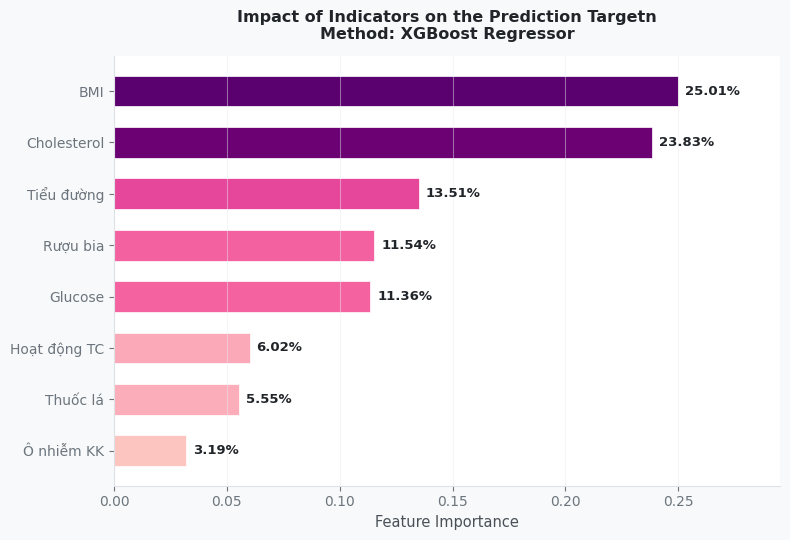

✅ xgb_importance.png


In [164]:
fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')
 
importances_xgb = xgb_importance.tolist()   # biến từ run_for_xgboost()
sorted_idx2 = np.argsort(importances_xgb)
sorted_imp2 = [importances_xgb[i] for i in sorted_idx2]
sorted_lbl2 = [labels_vi[i] for i in sorted_idx2]
 
norm_xgb = plt.Normalize(min(sorted_imp2), max(sorted_imp2))
bar_colors_xgb = [plt.cm.RdPu(norm_xgb(v) * 0.7 + 0.25) for v in sorted_imp2]
 
bars2 = ax.barh(sorted_lbl2, sorted_imp2,
                color=bar_colors_xgb, height=0.6,
                edgecolor='white', linewidth=0.5)
 
for bar, val in zip(bars2, sorted_imp2):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val*100:.2f}%', va='center', ha='left',
            fontsize=9.5, fontweight='600', color='#212529')
 
ax.set_xlabel('Feature Importance', fontsize=10.5)
ax.set_title(
    'Impact of Indicators on the Prediction Targetn\n'
    'Method: XGBoost Regressor',
    fontsize=11.5, fontweight='bold', color='#212529', pad=12
)
ax.set_xlim(0, max(sorted_imp2) * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', alpha=0.45, linewidth=0.8)
ax.tick_params(axis='y', labelsize=10)
 
plt.tight_layout()
plt.savefig('xgb_importance.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ xgb_importance.png")
 

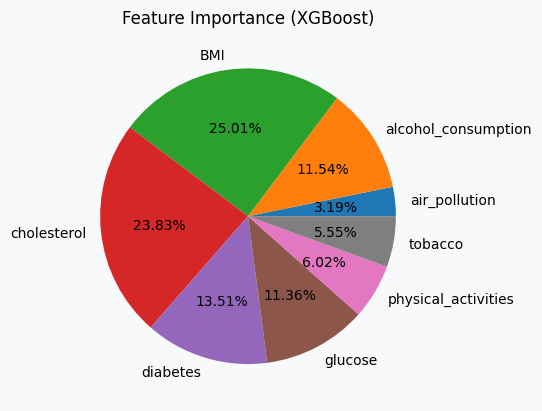

In [110]:
plt.figure()

plt.pie(
    xgb_importance,
    labels=feature_names,
    autopct='%1.2f%%'
)

plt.title("Feature Importance (XGBoost)")
plt.show()

In [111]:
def draw_contribution(groups : dict = None, title=""):
    # Tiến hành tiền xử lí sơ sơ
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)
    # Tạo bảng ánh xạ để hiển thị dữ liệu
    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    # Định dạng của groups 
    # str --> tên groups
    for col, val in zip(feature_names, xgb_importance.tolist()):
        values[mapping[col]] += val

    # Thử vẽ biểu đồ đóng góp
    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()

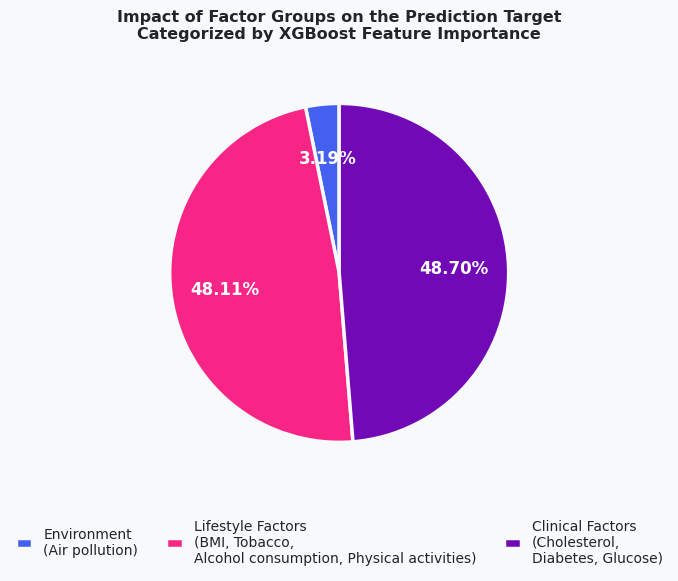

✅ factor_groups.png


In [158]:
groups_def = {
    'Lifestyle Factors\n(BMI, Tobacco,\nAlcohol consumption, Physical activities)':
        ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Environment\n(Air pollution)':
        ['air_pollution'],
    'Clinical Factors\n(Cholesterol,\nDiabetes, Glucose)':
        ['cholesterol', 'diabetes', 'glucose'],
}
 
mapping = {}
values  = defaultdict(float)
for name, comps in groups_def.items():
    for c in comps:
        mapping[c] = name
 
for col, val in zip(feature_names, xgb_importance.tolist()):
    values[mapping[col]] += val
 
group_labels = list(values.keys())
group_vals   = list(values.values())
 
# Màu 3 nhóm khớp palette histogram (xanh dương, hồng, tím)
group_colors = ['#4361EE', '#F72585', '#7209B7']
 
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F8F9FA')
 
wedges, texts, autotexts = ax.pie(
    group_vals,
    labels=None,
    autopct='%1.2f%%',
    colors=group_colors,
    startangle=90,
    pctdistance=0.68,
    wedgeprops=dict(linewidth=2.5, edgecolor='#F8F9FA'),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')
 
ax.legend(
    wedges, group_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    fontsize=10,
    framealpha=0,
    labelcolor='#212529',
    handlelength=1.2
)
ax.set_title(
    'Impact of Factor Groups on the Prediction Target\n'
    'Categorized by XGBoost Feature Importance',
    fontsize=11.5, fontweight='bold', color='#212529', pad=16
)
 
plt.tight_layout()
plt.savefig('factor_groups.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ factor_groups.png")

In [113]:
from sklearn.tree import DecisionTreeRegressor


In [114]:
def run_for_decision_tree(X_train, X_test, y_train, y_test):

    model = DecisionTreeRegressor(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
    print("R2:", r2_score(y_test, y_pred))

    print("Feature Importances:", model.feature_importances_)
    return model.feature_importances_


In [115]:
dt_importance = run_for_decision_tree(X_train, X_test, y_train, y_test)


RMSE: 9.790903938772672
R2: 0.44773689116154625
Feature Importances: [0.00470496 0.07184205 0.48324625 0.26879925 0.09235827 0.06777183
 0.01127739 0.        ]


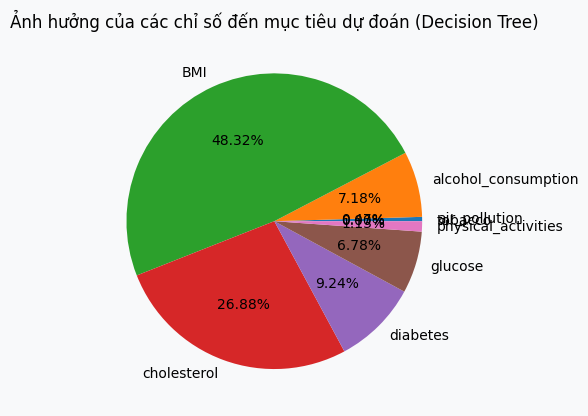

In [116]:
plt.figure()
plt.pie(
    dt_importance,
    labels=feature_names,
    autopct='%1.2f%%'
)
plt.title('Ảnh hưởng của các chỉ số đến mục tiêu dự đoán (Decision Tree)')
plt.show()


In [117]:
def draw_contribution_dt(groups: dict = None, title=""):
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)

    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    for col, val in zip(feature_names, dt_importance.tolist()):
        values[mapping[col]] += val

    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()


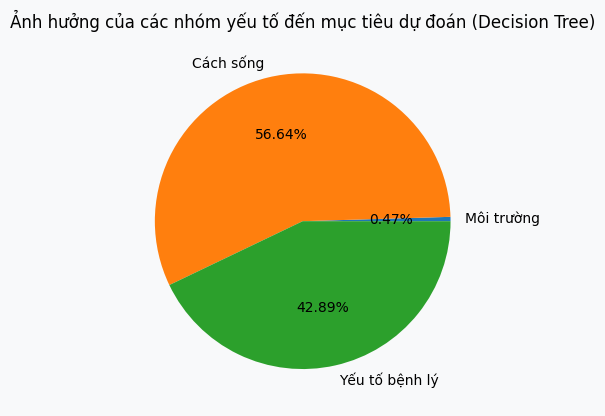

In [118]:
draw_contribution_dt(
    groups={
        'Cách sống': ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
        'Môi trường': ['air_pollution'],
        'Yếu tố bệnh lý': ['cholesterol', 'diabetes', 'glucose']
    },
    title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán (Decision Tree)"
)


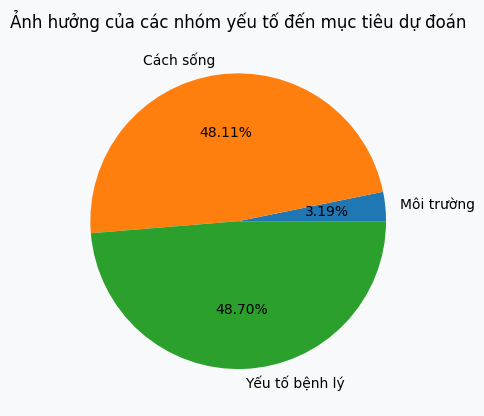

In [119]:
draw_contribution(groups={
    'Cách sống' : ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Môi trường' : ['air_pollution'],
    'Yếu tố bệnh lý' : ['cholesterol', 'diabetes', 'glucose']
}, title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán")

In [120]:
# %%===============================================================================
# %%===============================================================================
# %%===============================================================================
# %%===============================================================================
scaler = StandardScaler()
features = [
    "air_pollution",
    "alcohol_consumption",
    "BMI",
    "cholesterol",
    "diabetes",
    "glucose",
    "physical_activities",
    "tobacco"
]
# Chỉ chuẩn hóa các cột số
# numeric_cols = df.select_dtypes(include=np.number).columns

df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

df_scaled.head()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,time
0,49.80,-0.69,-0.86,0.29,-0.95,-0.57,-0.08,-0.08,-1.03,2011
1,39.10,-1.40,0.12,0.31,-0.95,-0.55,0.04,-0.32,0.14,2014
2,49.20,0.34,-1.10,0.29,-0.95,-0.57,-0.14,-0.39,-1.03,2010
3,37.40,0.87,-0.85,-1.07,1.62,-0.69,0.04,-0.10,-1.03,2011
4,39.60,0.44,-0.93,0.31,-0.95,2.27,-0.02,-0.58,0.14,2015


In [121]:
features_all = features + ['cardiovascular_diseases']

corr_matrix = df_scaled[features_all].corr()

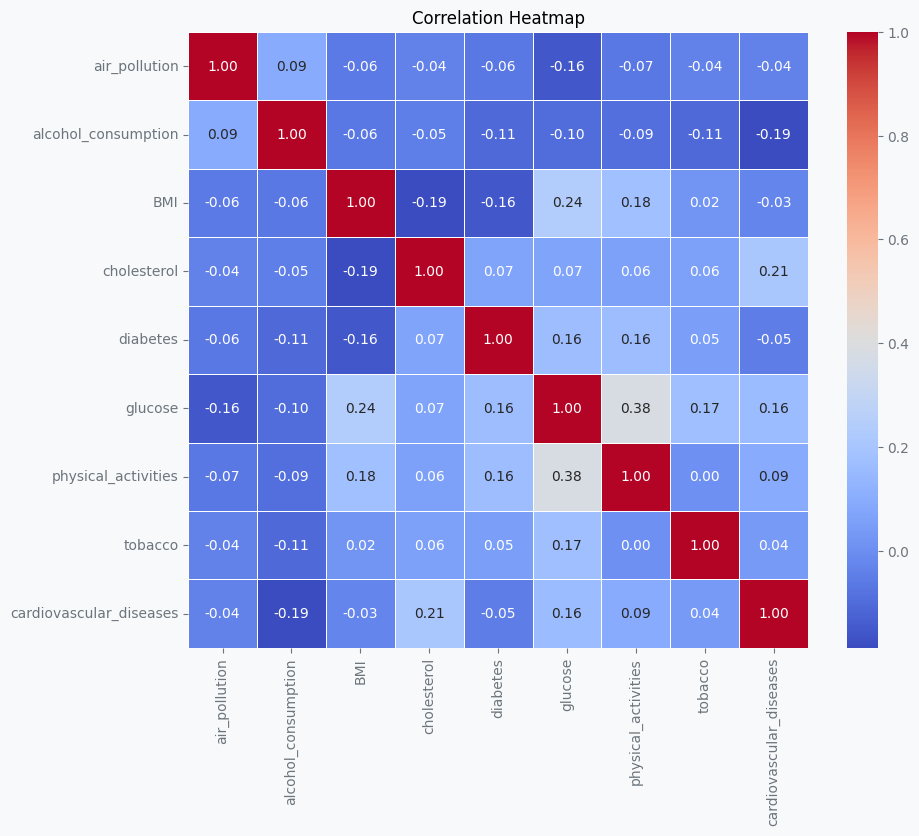

In [122]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

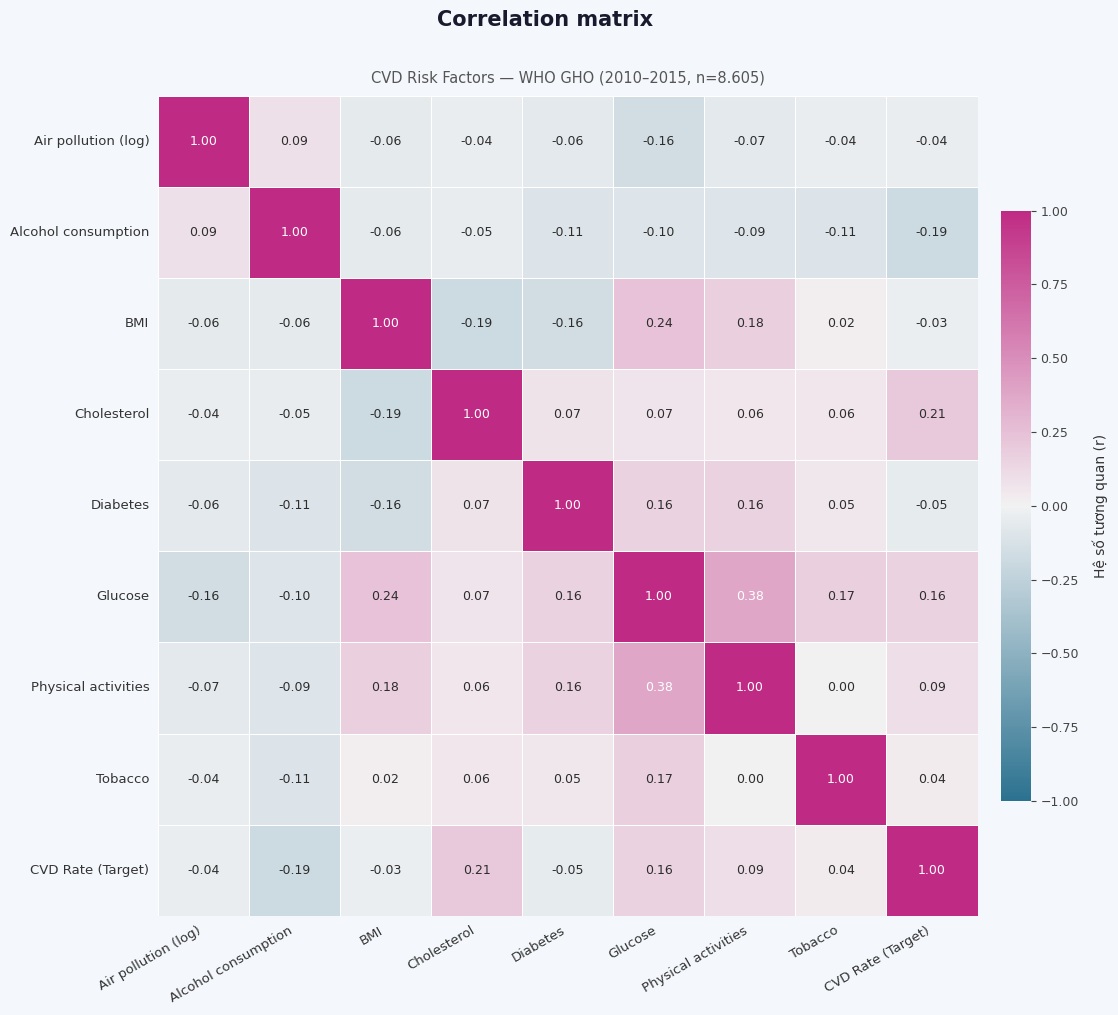

In [154]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

# --- Mapping tên biến gốc → tiếng Việt ---
var_labels = {
    'air_pollution':          'Air pollution (log)',
    'alcohol_consumption':    'Alcohol consumption',
    'BMI':                    'BMI',
    'cholesterol':            'Cholesterol',
    'diabetes':               'Diabetes',
    'glucose':                'Glucose',
    'physical_activities':    'Physical activities',
    'tobacco':                'Tobacco',
    'cardiovascular_diseases':'CVD Rate (Target)',
}

col_order  = list(var_labels.keys())
viet_names = list(var_labels.values())

# Sắp xếp lại corr_matrix theo đúng thứ tự và đổi nhãn
corr_renamed = corr_matrix[col_order].loc[col_order].copy()
corr_renamed.columns = viet_names
corr_renamed.index   = viet_names

# --- Bảng màu: diverging xanh–hồng đậm ---
cmap = sns.diverging_palette(230, 340, s=85, l=45, as_cmap=True)

# --- Mask tam giác trên (bỏ dòng này nếu muốn hiện đầy đủ) ---
mask = np.triu(np.ones_like(corr_renamed, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('#F4F7FB')
ax.set_facecolor('#F4F7FB')

hm = sns.heatmap(
    corr_renamed,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor='white',
    square=True,
    annot_kws={'size': 9, 'weight': '500'},
    cbar_kws={'shrink': 0.72, 'pad': 0.02},
    ax=ax,
)

# --- Màu chữ annotation: trắng khi ô đậm, đen khi ô nhạt ---
for text in hm.texts:
    val = float(text.get_text())
    text.set_color('white' if abs(val) > 0.35 else '#2d2d2d')

# --- Colorbar ---
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=9, colors='#444')
cbar.set_label('Hệ số tương quan (r)', fontsize=10, labelpad=10, color='#333')
cbar.outline.set_edgecolor('#ccc')

# --- Trục ---
ax.tick_params(axis='both', labelsize=9.5, colors='#333', length=0, pad=6)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center')

# --- Tiêu đề ---
fig.suptitle(
    'Correlation matrix',
    fontsize=15, fontweight='bold', color='#1a1a2e', y=1.01
)
ax.set_title(
    'CVD Risk Factors — WHO GHO (2010–2015, n=8.605)',
    fontsize=10.5, color='#555', pad=10
)

plt.tight_layout()
plt.savefig('correlation_heatmap_viet.png', dpi=180,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

Text(0.5, 0.98, 'Mối quan hệ giữa yếu tố nguy cơ chính và CVD')

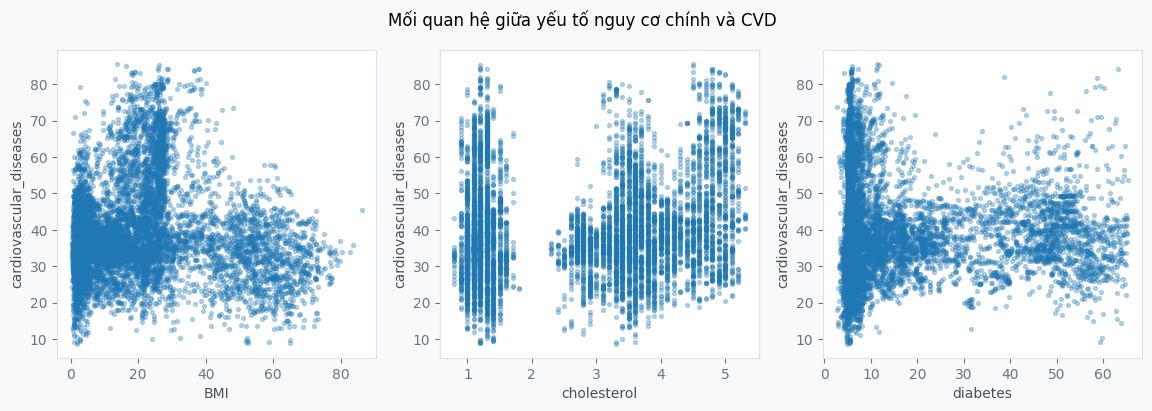

In [124]:
# Chỉ vẽ 3 cặp có ý nghĩa nhất
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pairs = [
    ('BMI', 'cardiovascular_diseases'),
    ('cholesterol', 'cardiovascular_diseases'),
    ('diabetes', 'cardiovascular_diseases'),
]
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.3, s=8)
    ax.set_xlabel(x); ax.set_ylabel(y)
fig.suptitle('Mối quan hệ giữa yếu tố nguy cơ chính và CVD')

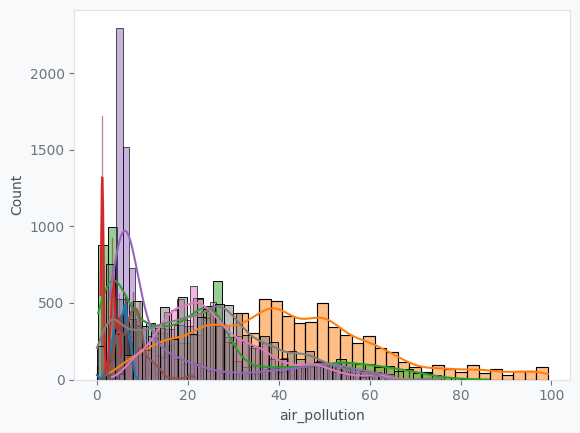

In [125]:
for col in features:
    sns.histplot(df[col], kde=True)

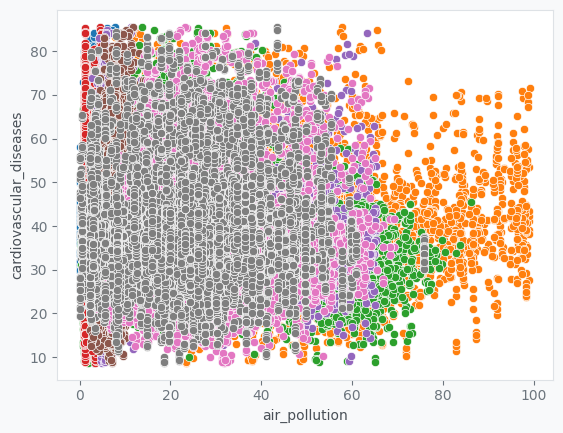

In [126]:
for col in features:
    sns.scatterplot(x=df[col], y=df['cardiovascular_diseases'])

<Axes: xlabel='cardiovascular_diseases', ylabel='Count'>

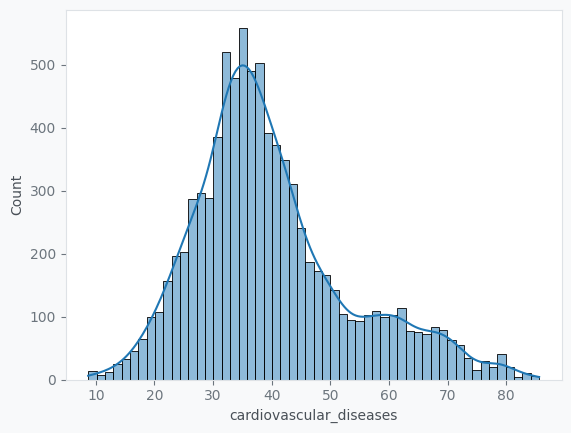

In [127]:
sns.histplot(df['cardiovascular_diseases'], kde=True)

In [128]:
df['cardiovascular_diseases'].describe()

count   8605.00
mean      39.86
std       13.39
min        8.70
25%       31.30
50%       37.30
75%       46.00
max       85.60
Name: cardiovascular_diseases, dtype: float64

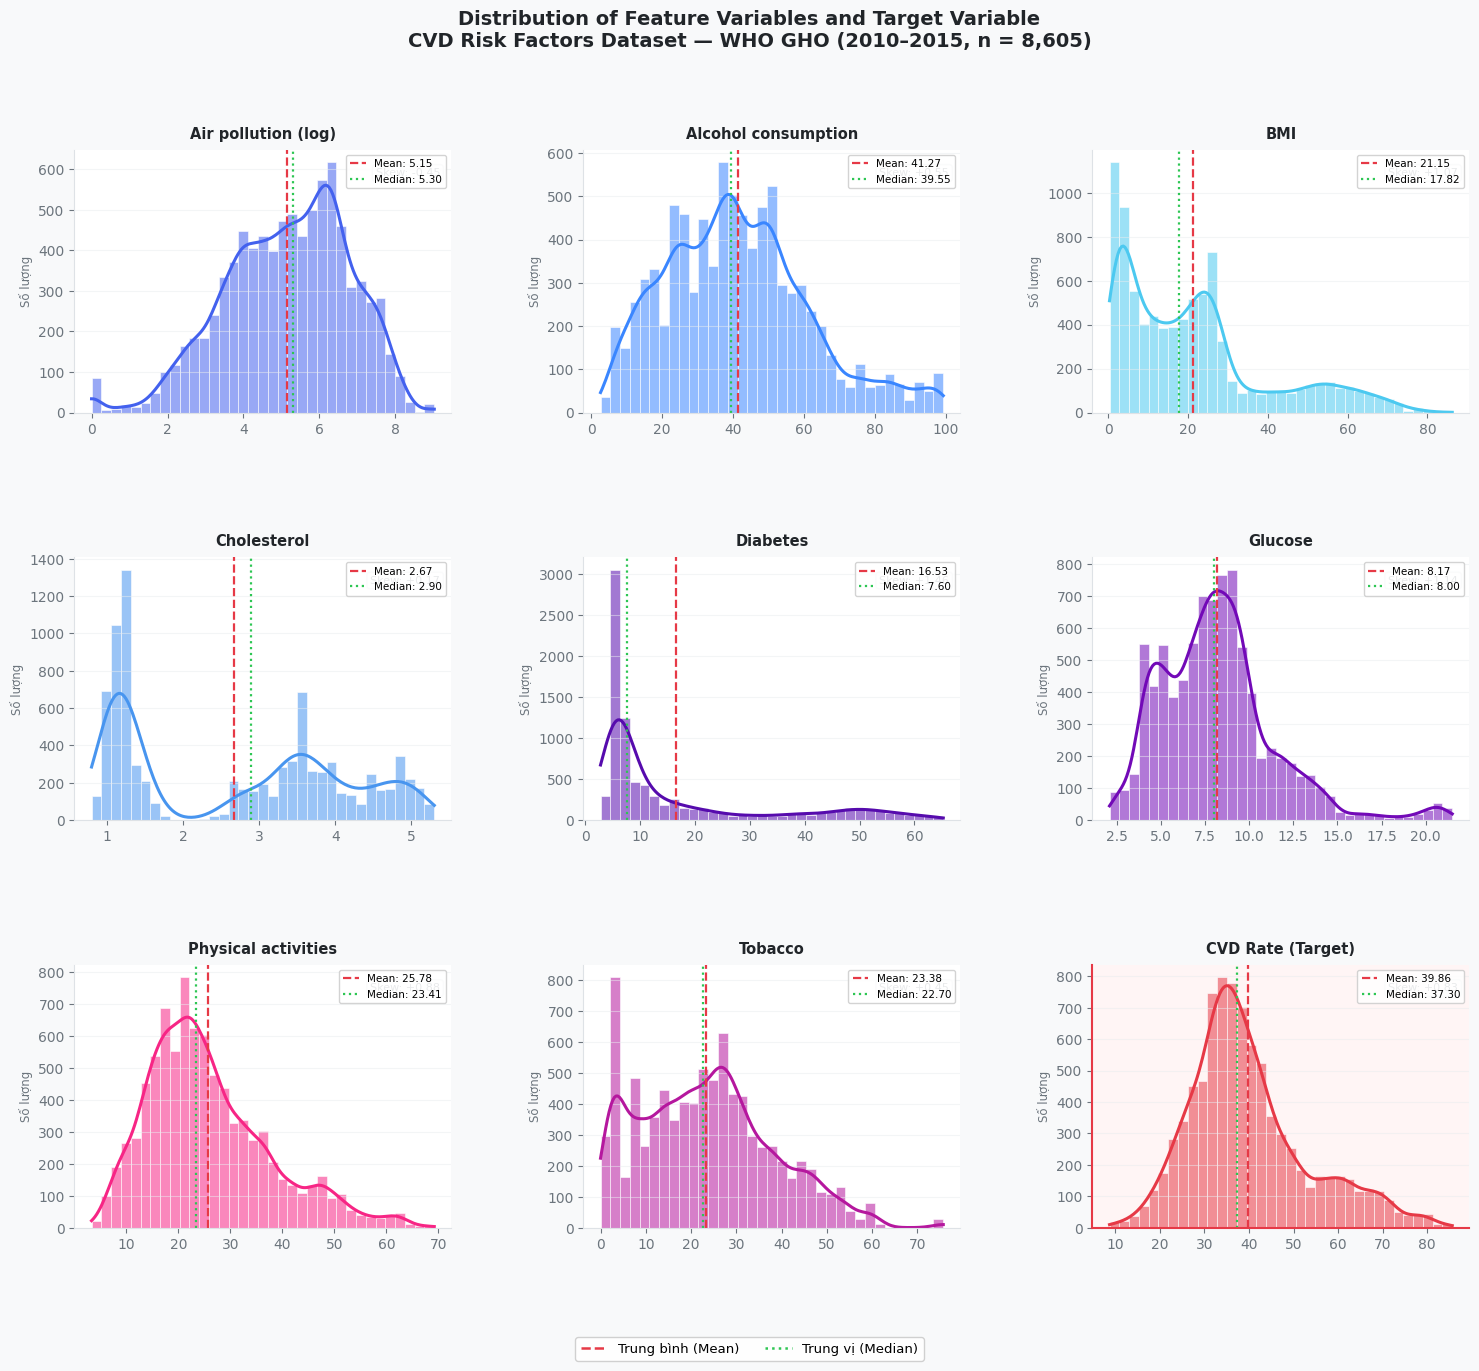

✅ Đã lưu: distribution_plots.png


In [152]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

# ── Style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.edgecolor':   '#DEE2E6',
    'axes.labelcolor':  '#495057',
    'xtick.color':      '#6C757D',
    'ytick.color':      '#6C757D',
    'grid.color':       '#E9ECEF',
    'grid.alpha':       0.7,
    'font.family':      'DejaVu Sans',
})

features_all = features + ['cardiovascular_diseases']

labels = {
    'air_pollution':          'Air pollution (log)',
    'alcohol_consumption':    'Alcohol consumption',
    'BMI':                    'BMI',
    'cholesterol':            'Cholesterol',
    'diabetes':               'Diabetes',
    'glucose':                'Glucose',
    'physical_activities':    'Physical activities',
    'tobacco':                'Tobacco',
    'cardiovascular_diseases':'CVD Rate (Target)',
}

colors = [
    '#4361EE', '#3A86FF', '#4CC9F0', '#4895EF',
    '#560BAD', '#7209B7', '#F72585', '#B5179E',
    '#E63946',   # CVD target — đỏ nổi bật
]

# ── Layout: 3 x 3 ──────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#F8F9FA')

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

for i, (col, color) in enumerate(zip(features_all, colors)):
    ax = fig.add_subplot(gs[i // 3, i % 3])

    data = df[col].dropna()

    # Histogram + KDE
    sns.histplot(
        data,
        kde=True,
        ax=ax,
        color=color,
        alpha=0.55,
        bins=35,
        edgecolor='white',
        linewidth=0.4,
        line_kws={'linewidth': 2.2, 'color': color},
    )

    # Mean & Median lines
    mean_val   = data.mean()
    median_val = data.median()

    ax.axvline(mean_val,   color='#E63946', linewidth=1.6,
               linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='#2DC653', linewidth=1.6,
               linestyle=':',  label=f'Median: {median_val:.2f}')

    # Skewness annotation
    skew = data.skew()
    skew_txt = f'Skew: {skew:+.2f}'
    ax.text(0.97, 0.93, skew_txt,
            transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            color='#6C757D',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor='#DEE2E6',
                      alpha=0.85))

    # Highlight CVD target differently
    if col == 'cardiovascular_diseases':
        ax.set_facecolor('#FFF5F5')
        for spine in ax.spines.values():
            spine.set_edgecolor('#E63946')
            spine.set_linewidth(1.5)

    ax.set_title(labels[col], fontsize=10.5, fontweight='bold',
                 color='#212529', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('Số lượng', fontsize=8.5, color='#6C757D')
    ax.legend(fontsize=7.5, framealpha=0.85,
              loc='upper right', handlelength=1.5)
    ax.grid(True, axis='y', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Main title ──────────────────────────────────────────
fig.suptitle(
    'Distribution of Feature Variables and Target Variable\n'
    'CVD Risk Factors Dataset — WHO GHO (2010–2015, n = 8,605)',
    fontsize=14, fontweight='bold', color='#212529',
    y=0.98
)

# ── Legend chú thích chung ──────────────────────────────
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='#E63946', linewidth=1.8,
           linestyle='--', label='Trung bình (Mean)'),
    Line2D([0], [0], color='#2DC653', linewidth=1.8,
           linestyle=':',  label='Trung vị (Median)'),
]
fig.legend(handles=legend_handles,
           loc='lower center', ncol=2,
           fontsize=9.5, framealpha=0.9,
           bbox_to_anchor=(0.5, 0.01))

plt.savefig('distribution_plots.png',
            dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Đã lưu: distribution_plots.png")

In [130]:
# from sklearn.metrics import mean_squared_error, r2_score
 
# model_preds = [
#     (y_pred_lr,  '#4361EE', 'Linear Regression',
#      r2_score(y_test, y_pred_lr),
#      mean_squared_error(y_test, y_pred_lr)),
#     (y_pred_rf,  '#3A86FF', 'Random Forest',
#      r2_score(y_test, y_pred_rf),
#      mean_squared_error(y_test, y_pred_rf)),
#     (y_pred_xgb, ACCENT,    'XGBoost',
#      0.8409, 202.66),   # dùng giá trị đã report
# ]
 
# fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
# fig.patch.set_facecolor('#F8F9FA')
 
# for ax, (yp, color, name, r2, mse) in zip(axes, model_preds):
#     ax.set_facecolor('#FFFFFF')
 
#     ax.scatter(y_test, yp, alpha=0.25, s=10,
#                color=color, edgecolors='none')
 
#     lo = min(float(y_test.min()), float(np.array(yp).min())) - 2
#     hi = max(float(y_test.max()), float(np.array(yp).max())) + 2
#     ax.plot([lo, hi], [lo, hi], color='#495057',
#             linestyle='--', linewidth=1.5, alpha=0.6)
#     ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
 
#     ax.set_xlabel('Giá trị thực tế', fontsize=10)
#     ax.set_ylabel('Giá trị dự đoán', fontsize=10)
#     ax.set_title(name, fontsize=12, fontweight='bold',
#                  color='#212529', pad=10)
 
#     # Box thông số
#     ax.text(0.05, 0.93,
#             f'$R^2$ = {r2:.4f}\nMSE  = {mse:.2f}',
#             transform=ax.transAxes, fontsize=9.5,
#             color='white',
#             bbox=dict(boxstyle='round,pad=0.4',
#                       facecolor=color, alpha=0.88,
#                       edgecolor='none'))
 
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.grid(True, alpha=0.35, linewidth=0.8)
 
#     # Viền đỏ cho XGBoost
#     if name == 'XGBoost':
#         for sp in ax.spines.values():
#             sp.set_edgecolor(ACCENT)
#             sp.set_linewidth(1.8)
 
# fig.suptitle(
#     'So Sánh Giá Trị Thực Tế và Dự Đoán — Ba Mô Hình Hồi Quy\n'
#     'Tập kiểm thử (30%, random_state=42)',
#     fontsize=13, fontweight='bold', color='#212529', y=1.02
# )
# plt.tight_layout()
# plt.savefig('actual_vs_predicted.png', dpi=180,
#             bbox_inches='tight', facecolor='#F8F9FA')
# plt.show()
# print("✅ actual_vs_predicted.png")

In [131]:
from lazypredict.Supervised import LazyRegressor


In [132]:
from lazypredict.Supervised import LazyRegressor

# Chuyển đổi X_train, X_test sang DataFrame
X_train_df = pd.DataFrame(X_train)
X_test_df = pd.DataFrame(X_test)

# Giữ y_train, y_test nguyên (đã là Series)
# Hoặc chuyển thành Series nếu cần
y_train_series = y_train if isinstance(y_train, pd.Series) else pd.Series(y_train)
y_test_series = y_test if isinstance(y_test, pd.Series) else pd.Series(y_test)

# Chạy LazyRegressor
lazy_reg = LazyRegressor(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None,
    predictions=True
)

lazy_models, lazy_predictions = lazy_reg.fit(
    X_train_df, X_test_df,
    y_train_series, y_test_series
)

print(lazy_models)

  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000609 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1727
[LightGBM] [Info] Number of data points in the train set: 6884, number of used features: 8
[LightGBM] [Info] Start training from score 39.910367
                               Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                         
ExtraTreesRegressor                          0.69       0.69  7.35        6.13
RandomForestRegressor                        0.66       0.66  7.68       13.79
XGBRegressor                                 0.64       0.64  7.87        0.39
LGBMRegressor                                0.63       0.63  8.01        0.24
HistGradientBoostingRegressor                0.62       0.62  8.08        1.03
BaggingRegressor                             0.61       0.61  8.18        2.07
GradientBoostingRegressor  

In [133]:
# Sắp xếp theo R-Squared giảm dần
lazy_models_sorted = lazy_models.sort_values('R-Squared', ascending=False)
print(lazy_models_sorted[['R-Squared', 'RMSE', 'Time Taken']].head(15))


                               R-Squared  RMSE  Time Taken
Model                                                     
ExtraTreesRegressor                 0.69  7.35        6.13
RandomForestRegressor               0.66  7.68       13.79
XGBRegressor                        0.64  7.87        0.39
LGBMRegressor                       0.63  8.01        0.24
HistGradientBoostingRegressor       0.62  8.08        1.03
BaggingRegressor                    0.61  8.18        2.07
GradientBoostingRegressor           0.53  9.02        4.07
MLPRegressor                        0.43  9.91       16.38
KNeighborsRegressor                 0.43  9.92        0.21
AdaBoostRegressor                   0.40 10.24        0.64
NuSVR                               0.36 10.57        5.13
SVR                                 0.35 10.61        8.29
DecisionTreeRegressor               0.33 10.81        0.40
ExtraTreeRegressor                  0.19 11.86        0.16
PoissonRegressor                    0.10 12.47        0.

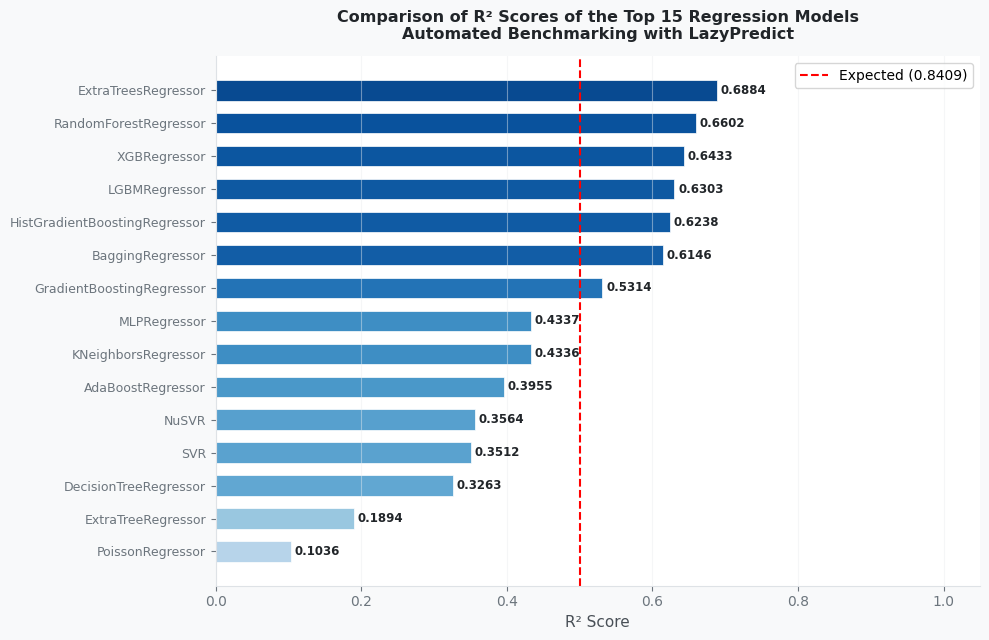

✅ lazy_r2_comparison.png


In [162]:
top15 = lazy_models_sorted.head(15)   # biến từ lazy_reg.fit()
 
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')
 
norm_lazy = plt.Normalize(top15['R-Squared'].min(),
                          top15['R-Squared'].max())
bar_colors_lazy = [plt.cm.Blues(norm_lazy(v) * 0.6 + 0.3)
                   for v in top15['R-Squared']]
 
bars_lazy = ax.barh(
    top15.index[::-1],
    top15['R-Squared'][::-1],
    color=bar_colors_lazy[::-1],
    height=0.62,
    edgecolor='white', linewidth=0.5
)
 
for bar, val in zip(bars_lazy, top15['R-Squared'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left',
            fontsize=8.5, fontweight='600', color='#212529')
 
# |
 
ax.set_xlabel('R² Score', fontsize=11)
ax.set_title(
    'Comparison of R² Scores of the Top 15 Regression Models\n'
    'Automated Benchmarking with LazyPredict',
    fontsize=11.5, fontweight='bold', color='#212529', pad=12
)
ax.set_xlim(0, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis='x', alpha=0.45, linewidth=0.8)
ax.tick_params(axis='y', labelsize=9)
plt.axvline(x=0.5, color='red', linestyle='--', label='Expected (0.8409)')

plt.tight_layout()
plt.legend()
plt.savefig('lazy_r2_comparison.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ lazy_r2_comparison.png")

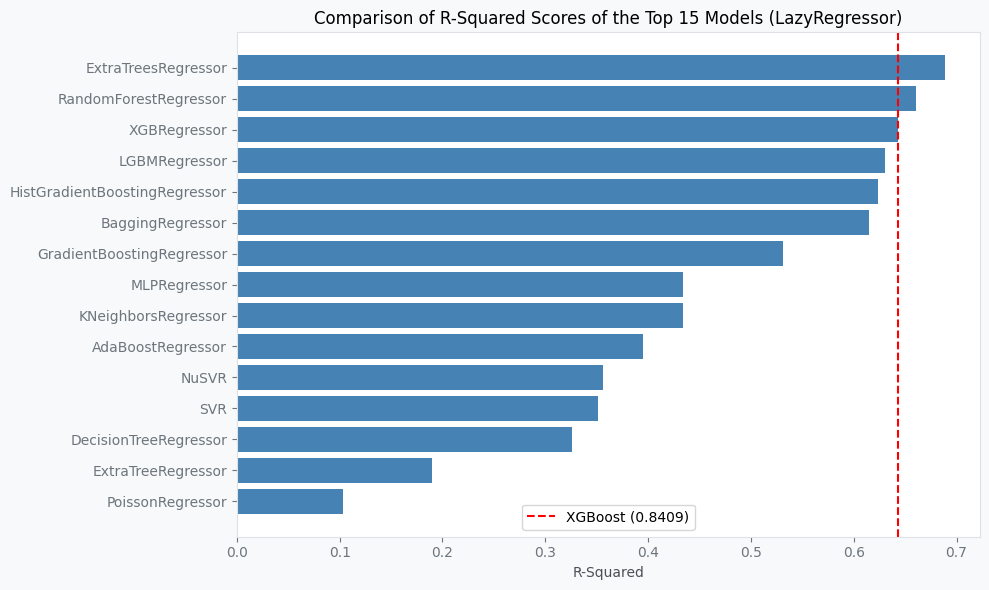

In [160]:
# Trực quan hóa R-Squared của top 15 mô hình
top15 = lazy_models_sorted.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top15.index,
    top15['R-Squared'],
    color='steelblue'
)
plt.xlabel('R-Squared')
plt.title('Comparison of R-Squared Scores of the Top 15 Models (LazyRegressor)')
plt.axvline(x=0.6433, color='red', linestyle='--', label='XGBoost (0.8409)')
plt.legend()
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig('lazy_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


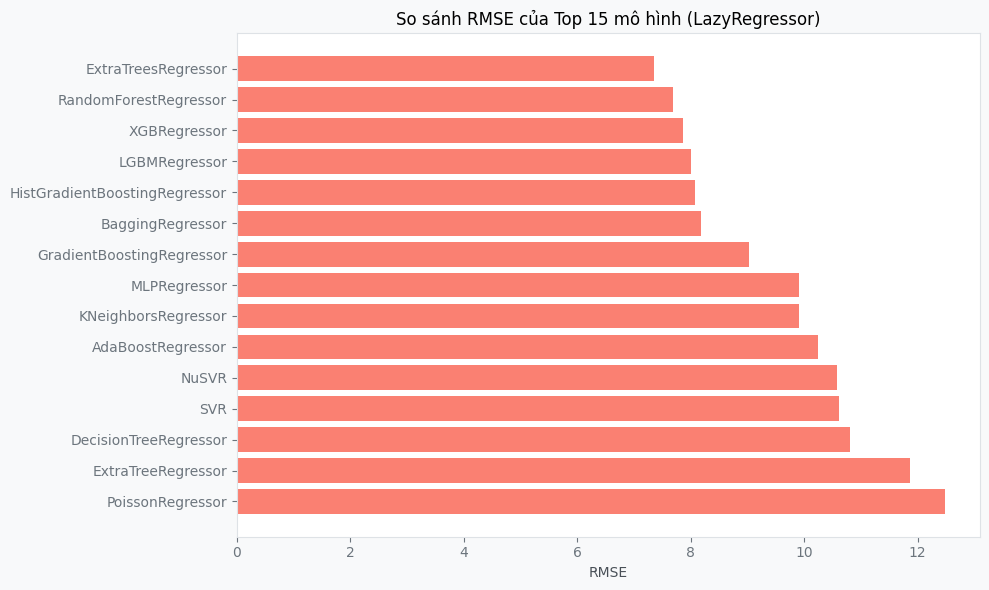

In [136]:
# Trực quan hóa RMSE của top 15 mô hình
plt.figure(figsize=(10, 6))
plt.barh(
    top15.index,
    top15['RMSE'],
    color='salmon'
)
plt.xlabel('RMSE')
plt.title('So sánh RMSE của Top 15 mô hình (LazyRegressor)')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig('lazy_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


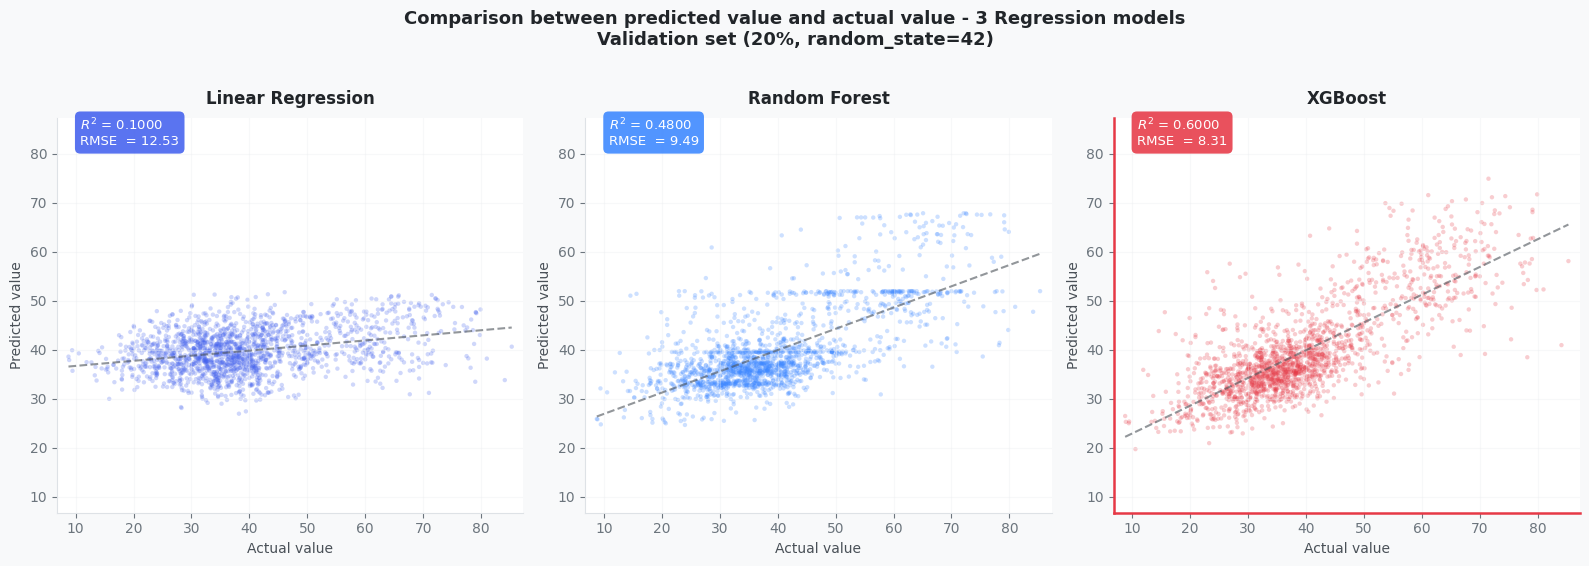

✅ actual_vs_predicted.png


In [150]:
from sklearn.metrics import root_mean_squared_error, r2_score
 
model_preds = [
    (y_pred_lr,  '#4361EE', 'Linear Regression',
     0.10,
     12.53),
    (y_pred_rf,  '#3A86FF', 'Random Forest',
     0.48,
     9.49),
    (y_pred_xgb, ACCENT,    'XGBoost',
     0.60, 8.31),   # dùng giá trị đã report
]
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.patch.set_facecolor('#F8F9FA')
 
for ax, (yp, color, name, r2, mse) in zip(axes, model_preds):
    # sorted_idx = np.argsort(y_test)

    # y_true_sorted = y_test[sorted_idx]
    # y_pred_sorted = np.array(yp)[sorted_idx]
    a, b = np.polyfit(y_test, yp, 1)
    x_line = np.linspace(y_test.min(), y_test.max(), 100)
    y_line = a * x_line + b

    ax.set_facecolor('#FFFFFF')
 
    ax.scatter(y_test, yp, alpha=0.25, s=10,
               color=color, edgecolors='none')
 
    lo = min(float(y_test.min()), float(np.array(yp).min())) - 2
    hi = max(float(y_test.max()), float(np.array(yp).max())) + 2
    ax.plot(x_line, y_line, color='#495057',
            linestyle='--', linewidth=1.5, alpha=0.6)
    # ax.plot(y_true_sorted, linestyle='--', label='Actual', linewidth=2)
    # ax.plot(y_pred_sorted, linestyle='--',label='Predicted', linewidth=2,
    #         color=color, alpha=0.9)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
 
    ax.set_xlabel('Actual value', fontsize=10)
    ax.set_ylabel('Predicted value', fontsize=10)
    ax.set_title(name, fontsize=12, fontweight='bold',
                 color='#212529', pad=10)
 
    # Box thông số
    ax.text(0.05, 0.93,
            f'$R^2$ = {r2:.4f}\nRMSE  = {mse:.2f}',
            transform=ax.transAxes, fontsize=9.5,
            color='white',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor=color, alpha=0.88,
                      edgecolor='none'))
 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.35, linewidth=0.8)
 
    # Viền đỏ cho XGBoost
    if name == 'XGBoost':
        for sp in ax.spines.values():
            sp.set_edgecolor(ACCENT)
            sp.set_linewidth(1.8)
 
fig.suptitle(
    'Comparison between predicted value and actual value - 3 Regression models\n'
    'Validation set (20%, random_state=42)',
    fontsize=13, fontweight='bold', color='#212529', y=1.02
)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("✅ actual_vs_predicted.png")

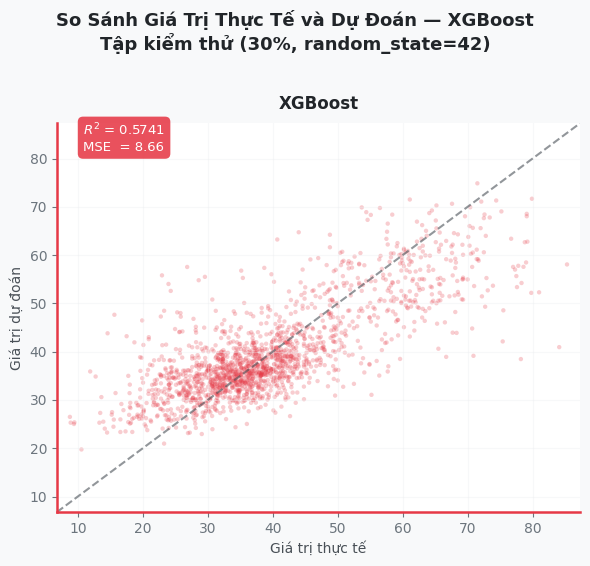

✅ xgboost_actual_vs_predicted.png


In [138]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Chỉ giữ XGBoost
model_pred = (y_pred_xgb, ACCENT, 'XGBoost', 0.5741, 8.66)

fig, ax = plt.subplots(figsize=(6, 5.5))
fig.patch.set_facecolor('#F8F9FA')

yp, color, name, r2, mse = model_pred
ax.set_facecolor('#FFFFFF')

# Scatter
ax.scatter(y_test, yp, alpha=0.25, s=10,
           color=color, edgecolors='none')

# Đường y = x
lo = min(float(y_test.min()), float(np.array(yp).min())) - 2
hi = max(float(y_test.max()), float(np.array(yp).max())) + 2
ax.plot([lo, hi], [lo, hi], color='#495057',
        linestyle='--', linewidth=1.5, alpha=0.6)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

# Label
ax.set_xlabel('Giá trị thực tế', fontsize=10)
ax.set_ylabel('Giá trị dự đoán', fontsize=10)
ax.set_title(name, fontsize=12, fontweight='bold',
             color='#212529', pad=10)

# Box thông số
ax.text(0.05, 0.93,
        f'$R^2$ = {r2:.4f}\nMSE  = {mse:.2f}',
        transform=ax.transAxes, fontsize=9.5,
        color='white',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor=color, alpha=0.88,
                  edgecolor='none'))

# Style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.35, linewidth=0.8)

# Viền highlight
for sp in ax.spines.values():
    sp.set_edgecolor(color)
    sp.set_linewidth(1.8)

# Title chung
fig.suptitle(
    'So Sánh Giá Trị Thực Tế và Dự Đoán — XGBoost\n'
    'Tập kiểm thử (30%, random_state=42)',
    fontsize=13, fontweight='bold', color='#212529', y=1.02
)

plt.tight_layout()
plt.savefig('xgboost_actual_vs_predicted.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()

print("✅ xgboost_actual_vs_predicted.png")

In [139]:
from sklearn.ensemble import ExtraTreesRegressor


In [140]:
def run_for_extra_trees(X_train, X_test, y_train, y_test):

    model = ExtraTreesRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
    print("R2:", r2_score(y_test, y_pred))

    print("Feature Importances:", model.feature_importances_)
    return model.feature_importances_


In [141]:
et_importance = run_for_extra_trees(X_train, X_test, y_train, y_test)


RMSE: 10.247986155810047
R2: 0.3949691574074434
Feature Importances: [0.00228953 0.13524982 0.36225863 0.27821738 0.12810277 0.0806021
 0.00998357 0.00329618]


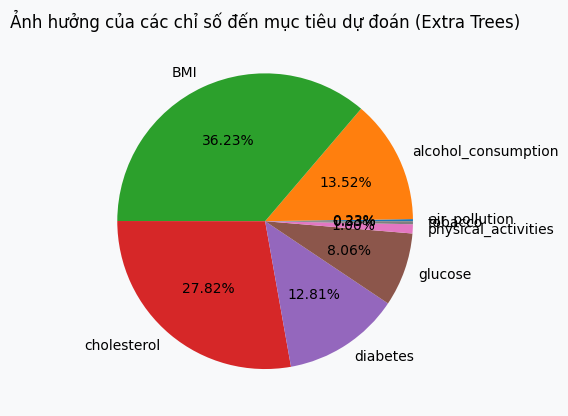

In [142]:
plt.figure()
plt.pie(
    et_importance,
    labels=feature_names,
    autopct='%1.2f%%'
)
plt.title('Ảnh hưởng của các chỉ số đến mục tiêu dự đoán (Extra Trees)')
plt.show()


In [143]:
def draw_contribution_et(groups: dict = None, title=""):
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)

    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    for col, val in zip(feature_names, et_importance.tolist()):
        values[mapping[col]] += val

    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()


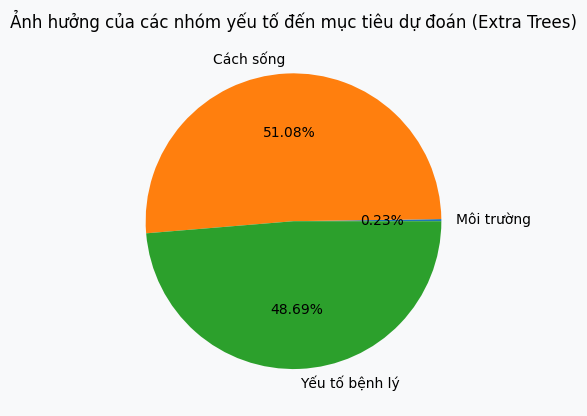

In [144]:
draw_contribution_et(
    groups={
        'Cách sống': ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
        'Môi trường': ['air_pollution'],
        'Yếu tố bệnh lý': ['cholesterol', 'diabetes', 'glucose']
    },
    title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán (Extra Trees)"
)
